# Q3. Feature Engineering and Regression Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Date Feature Engineering

In [2]:
# Load data
df_q3 = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert to datetime
df_q3['transaction_date'] = pd.to_datetime(df_q3['transaction_date'])

# Extract year, month, day_of_week
df_q3['year'] = df_q3['transaction_date'].dt.year
df_q3['month'] = df_q3['transaction_date'].dt.month
df_q3['day_of_week'] = df_q3['transaction_date'].dt.dayofweek

# Create is_month_end
df_q3['is_month_end'] = (df_q3['transaction_date'].dt.day >= 25).astype(int)

# Display sample to confirm new columns
display(df_q3[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

,transaction_date,year,month,day_of_week,is_month_end
240,2022-07-22,2022,7,4,0
1052,2024-08-28,2024,8,2,1
216,2022-06-30,2022,6,3,1
777,2024-01-20,2024,1,5,0
546,2023-06-18,2023,6,6,0


## 2. Temporal Train-Test Split

In [3]:
# Sort data by transaction_date
df_q3 = df_q3.sort_values('transaction_date').reset_index(drop=True)

# Separate Target and Features
X = df_q3.drop(columns=['items_sold', 'transaction_date']) # Dropping date as features are extracted
y = df_q3['items_sold']

# Calculate split index
split_idx = int(len(df_q3) * 0.8)

# Split (80% train, 20% most recent test)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} records")
print(f"Test set: {X_test.shape[0]} records")

Training set: 960 records
Test set: 240 records


**Why a random split is inappropriate:**\nIn time-series or time-ordered data, future events often depend on past events, and patterns may drift over time. A random split would introduce the 'future' into the training set, causing data leakage. By training on past data and testing on future data, we accurately simulate real-world conditions where models must predict future unknown outcomes based solely on historical data.

## 3. Preprocessing Pipeline

In [4]:
# Define categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# We define the complete pipelines later for each model as the requirement states 
# "The pipeline must be fit only on the training set and applied to both train and test sets."
# Scikit-learn pipelines handle this perfectly when the estimator is included.
print("Preprocessing ColumnTransformer constructed successfully.")

Preprocessing ColumnTransformer constructed successfully.


## 4. Model Training and Evaluation

--- Linear Regression ---
RMSE: 27.1215
MAE:  21.0529

--- Random Forest ---
RMSE: 30.8416
MAE:  24.2406



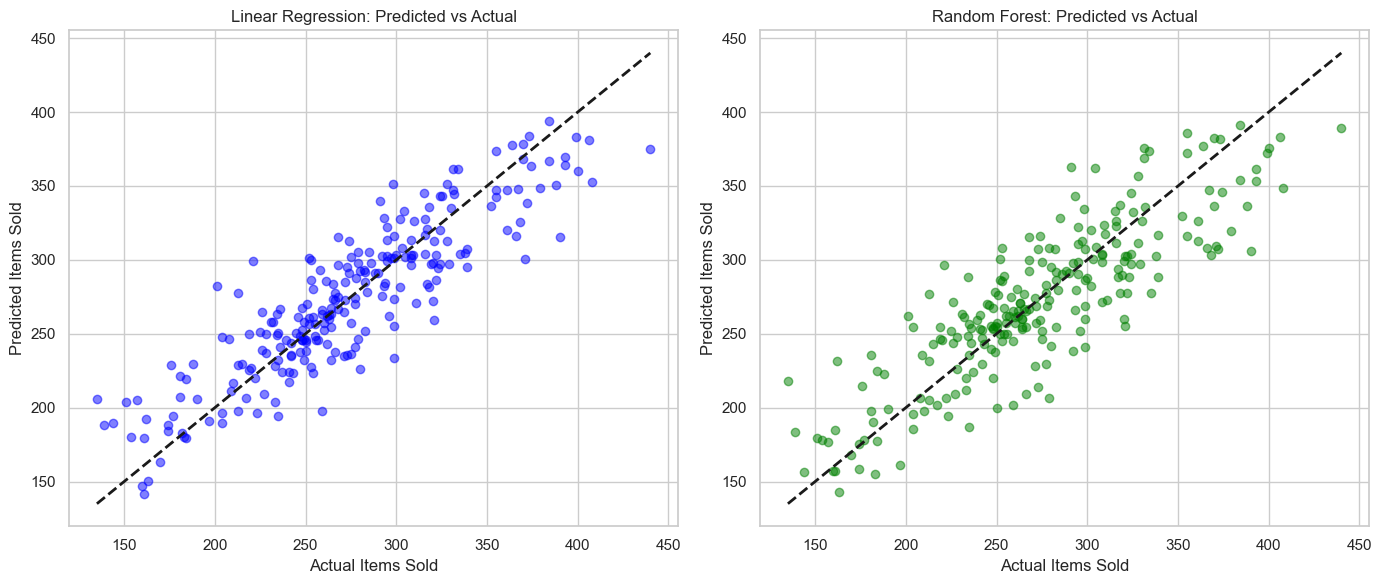

Top 5 Most Influential Features:


,Feature,Importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208


In [5]:
# Define explicit Pipelines for both models
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])

# Train models
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# Predictions
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# Metrics evaluation
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}\n")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

# Parity Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs Actual')
axes[0].set_xlabel('Actual Items Sold')
axes[0].set_ylabel('Predicted Items Sold')

axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title('Random Forest: Predicted vs Actual')
axes[1].set_xlabel('Actual Items Sold')
axes[1].set_ylabel('Predicted Items Sold')

plt.tight_layout()
plt.show()

# Feature Importances from Random Forest
rf_model = pipeline_rf.named_steps['regressor']
# Get feature names after one-hot encoding
cat_features = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(cat_features) + numerical_cols

importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("Top 5 Most Influential Features:")
display(feature_imp_df.head(5))